# ENTRENAMIENTO DE MODELOS

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Análisis exploratorio

In [33]:
df_portatiles_mod = pd.read_csv("data/train_kaggle_procesado.csv", sep=",")
df_portatiles_mod.head()

,id,Company,TypeName,Inches,Ram,OpSys,Weight,ScreenWidth,ScreenHeight,Touchscreen,...,marca_cpu,velocidad_cpu,total_almacenamiento_gb,ssd,hdd,flash,GPU_Intel,GPU_AMD,GPU_Nvidia,Price_euros
0,268,4,3,15.6,8.0,5,2.36,1366,768,0,...,1,2.7,1024.0,0,1,0,0,1,0,749.00
1,347,2,3,15.6,4.0,5,2.00,1366,768,0,...,1,1.1,1024.0,0,1,0,1,0,0,449.00
2,353,16,3,13.3,8.0,7,1.20,1920,1080,0,...,1,2.3,256.0,1,0,0,1,0,0,1460.00
3,578,4,1,15.6,16.0,5,4.42,3840,2160,0,...,1,2.8,1280.0,1,1,0,0,0,1,2868.99
4,42,4,4,12.5,8.0,7,1.26,1920,1080,1,...,1,2.4,256.0,1,0,0,1,0,0,1713.37


In [34]:
df_portatiles_mod["Resolucion"] = df_portatiles_mod["ScreenWidth"] * df_portatiles_mod["ScreenHeight"]

In [35]:
df_portatiles_mod.head()

,id,Company,TypeName,Inches,Ram,OpSys,Weight,ScreenWidth,ScreenHeight,Touchscreen,...,velocidad_cpu,total_almacenamiento_gb,ssd,hdd,flash,GPU_Intel,GPU_AMD,GPU_Nvidia,Price_euros,Resolucion
0,268,4,3,15.6,8.0,5,2.36,1366,768,0,...,2.7,1024.0,0,1,0,0,1,0,749.00,1049088
1,347,2,3,15.6,4.0,5,2.00,1366,768,0,...,1.1,1024.0,0,1,0,1,0,0,449.00,1049088
2,353,16,3,13.3,8.0,7,1.20,1920,1080,0,...,2.3,256.0,1,0,0,1,0,0,1460.00,2073600
3,578,4,1,15.6,16.0,5,4.42,3840,2160,0,...,2.8,1280.0,1,1,0,0,0,1,2868.99,8294400
4,42,4,4,12.5,8.0,7,1.26,1920,1080,1,...,2.4,256.0,1,0,0,1,0,0,1713.37,2073600


In [36]:
df_portatiles_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       912 non-null    int64  
 1   Company                  912 non-null    int64  
 2   TypeName                 912 non-null    int64  
 3   Inches                   912 non-null    float64
 4   Ram                      912 non-null    float64
 5   OpSys                    912 non-null    int64  
 6   Weight                   912 non-null    float64
 7   ScreenWidth              912 non-null    int64  
 8   ScreenHeight             912 non-null    int64  
 9   Touchscreen              912 non-null    int64  
 10  IPS                      912 non-null    int64  
 11  marca_cpu                912 non-null    int64  
 12  velocidad_cpu            912 non-null    float64
 13  total_almacenamiento_gb  912 non-null    float64
 14  ssd                      9

In [37]:
df_portatiles_mod.describe()

,id,Company,TypeName,Inches,Ram,OpSys,Weight,ScreenWidth,ScreenHeight,Touchscreen,...,velocidad_cpu,total_almacenamiento_gb,ssd,hdd,flash,GPU_Intel,GPU_AMD,GPU_Nvidia,Price_euros,Resolucion
count,912.000000,912.000000,912.000000,912.000000,912.000000,912.000000,912.000000,912.000000,912.000000,912.00000,...,912.000000,912.000000,912.000000,912.000000,912.000000,912.000000,912.000000,912.000000,912.000000,9.120000e+02
mean,645.091009,6.449561,2.589912,15.011404,8.188596,4.796053,2.032112,1890.050439,1067.899123,0.14693,...,2.287895,594.109649,0.643640,0.437500,0.059211,0.572368,0.133772,0.293860,1108.122873,2.164425e+06
std,380.313813,4.146293,1.232841,1.411744,4.899827,1.075659,0.653772,506.007321,290.338307,0.35423,...,0.513277,471.379922,0.479186,0.496351,0.236148,0.495007,0.340594,0.455778,714.597741,1.431201e+06
min,0.000000,0.000000,0.000000,10.100000,2.000000,0.000000,0.690000,1366.000000,768.000000,0.00000,...,0.900000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,174.000000,1.049088e+06
25%,319.750000,4.000000,2.000000,14.000000,4.000000,5.000000,1.500000,1366.000000,768.000000,0.00000,...,2.000000,256.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,589.000000,1.049088e+06
50%,636.500000,7.000000,3.000000,15.600000,8.000000,5.000000,2.040000,1920.000000,1080.000000,0.00000,...,2.500000,500.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,949.000000,2.073600e+06
75%,980.250000,10.000000,3.000000,15.600000,8.000000,5.000000,2.300000,1920.000000,1080.000000,0.00000,...,2.700000,1024.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1458.500000,2.073600e+06
max,1302.000000,18.000000,5.000000,18.400000,32.000000,8.000000,4.600000,3840.000000,2160.000000,1.00000,...,3.600000,2560.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6099.000000,8.294400e+06


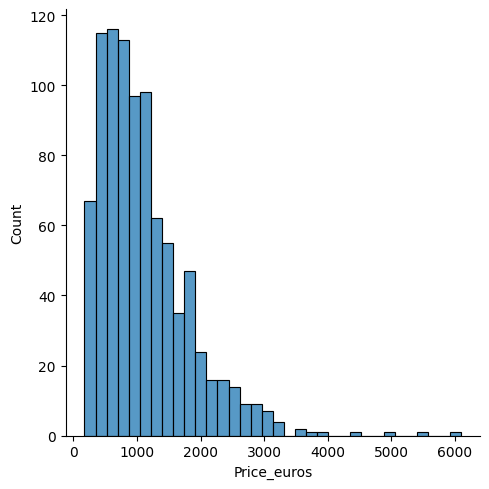

In [38]:
sns.displot(df_portatiles_mod["Price_euros"])

<Axes: ylabel='Price_euros'>

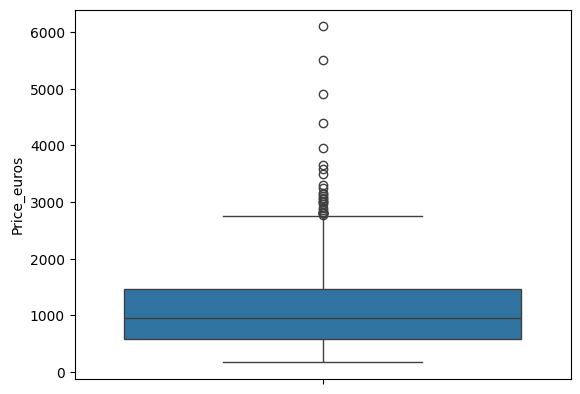

In [39]:
sns.boxplot(df_portatiles_mod["Price_euros"])

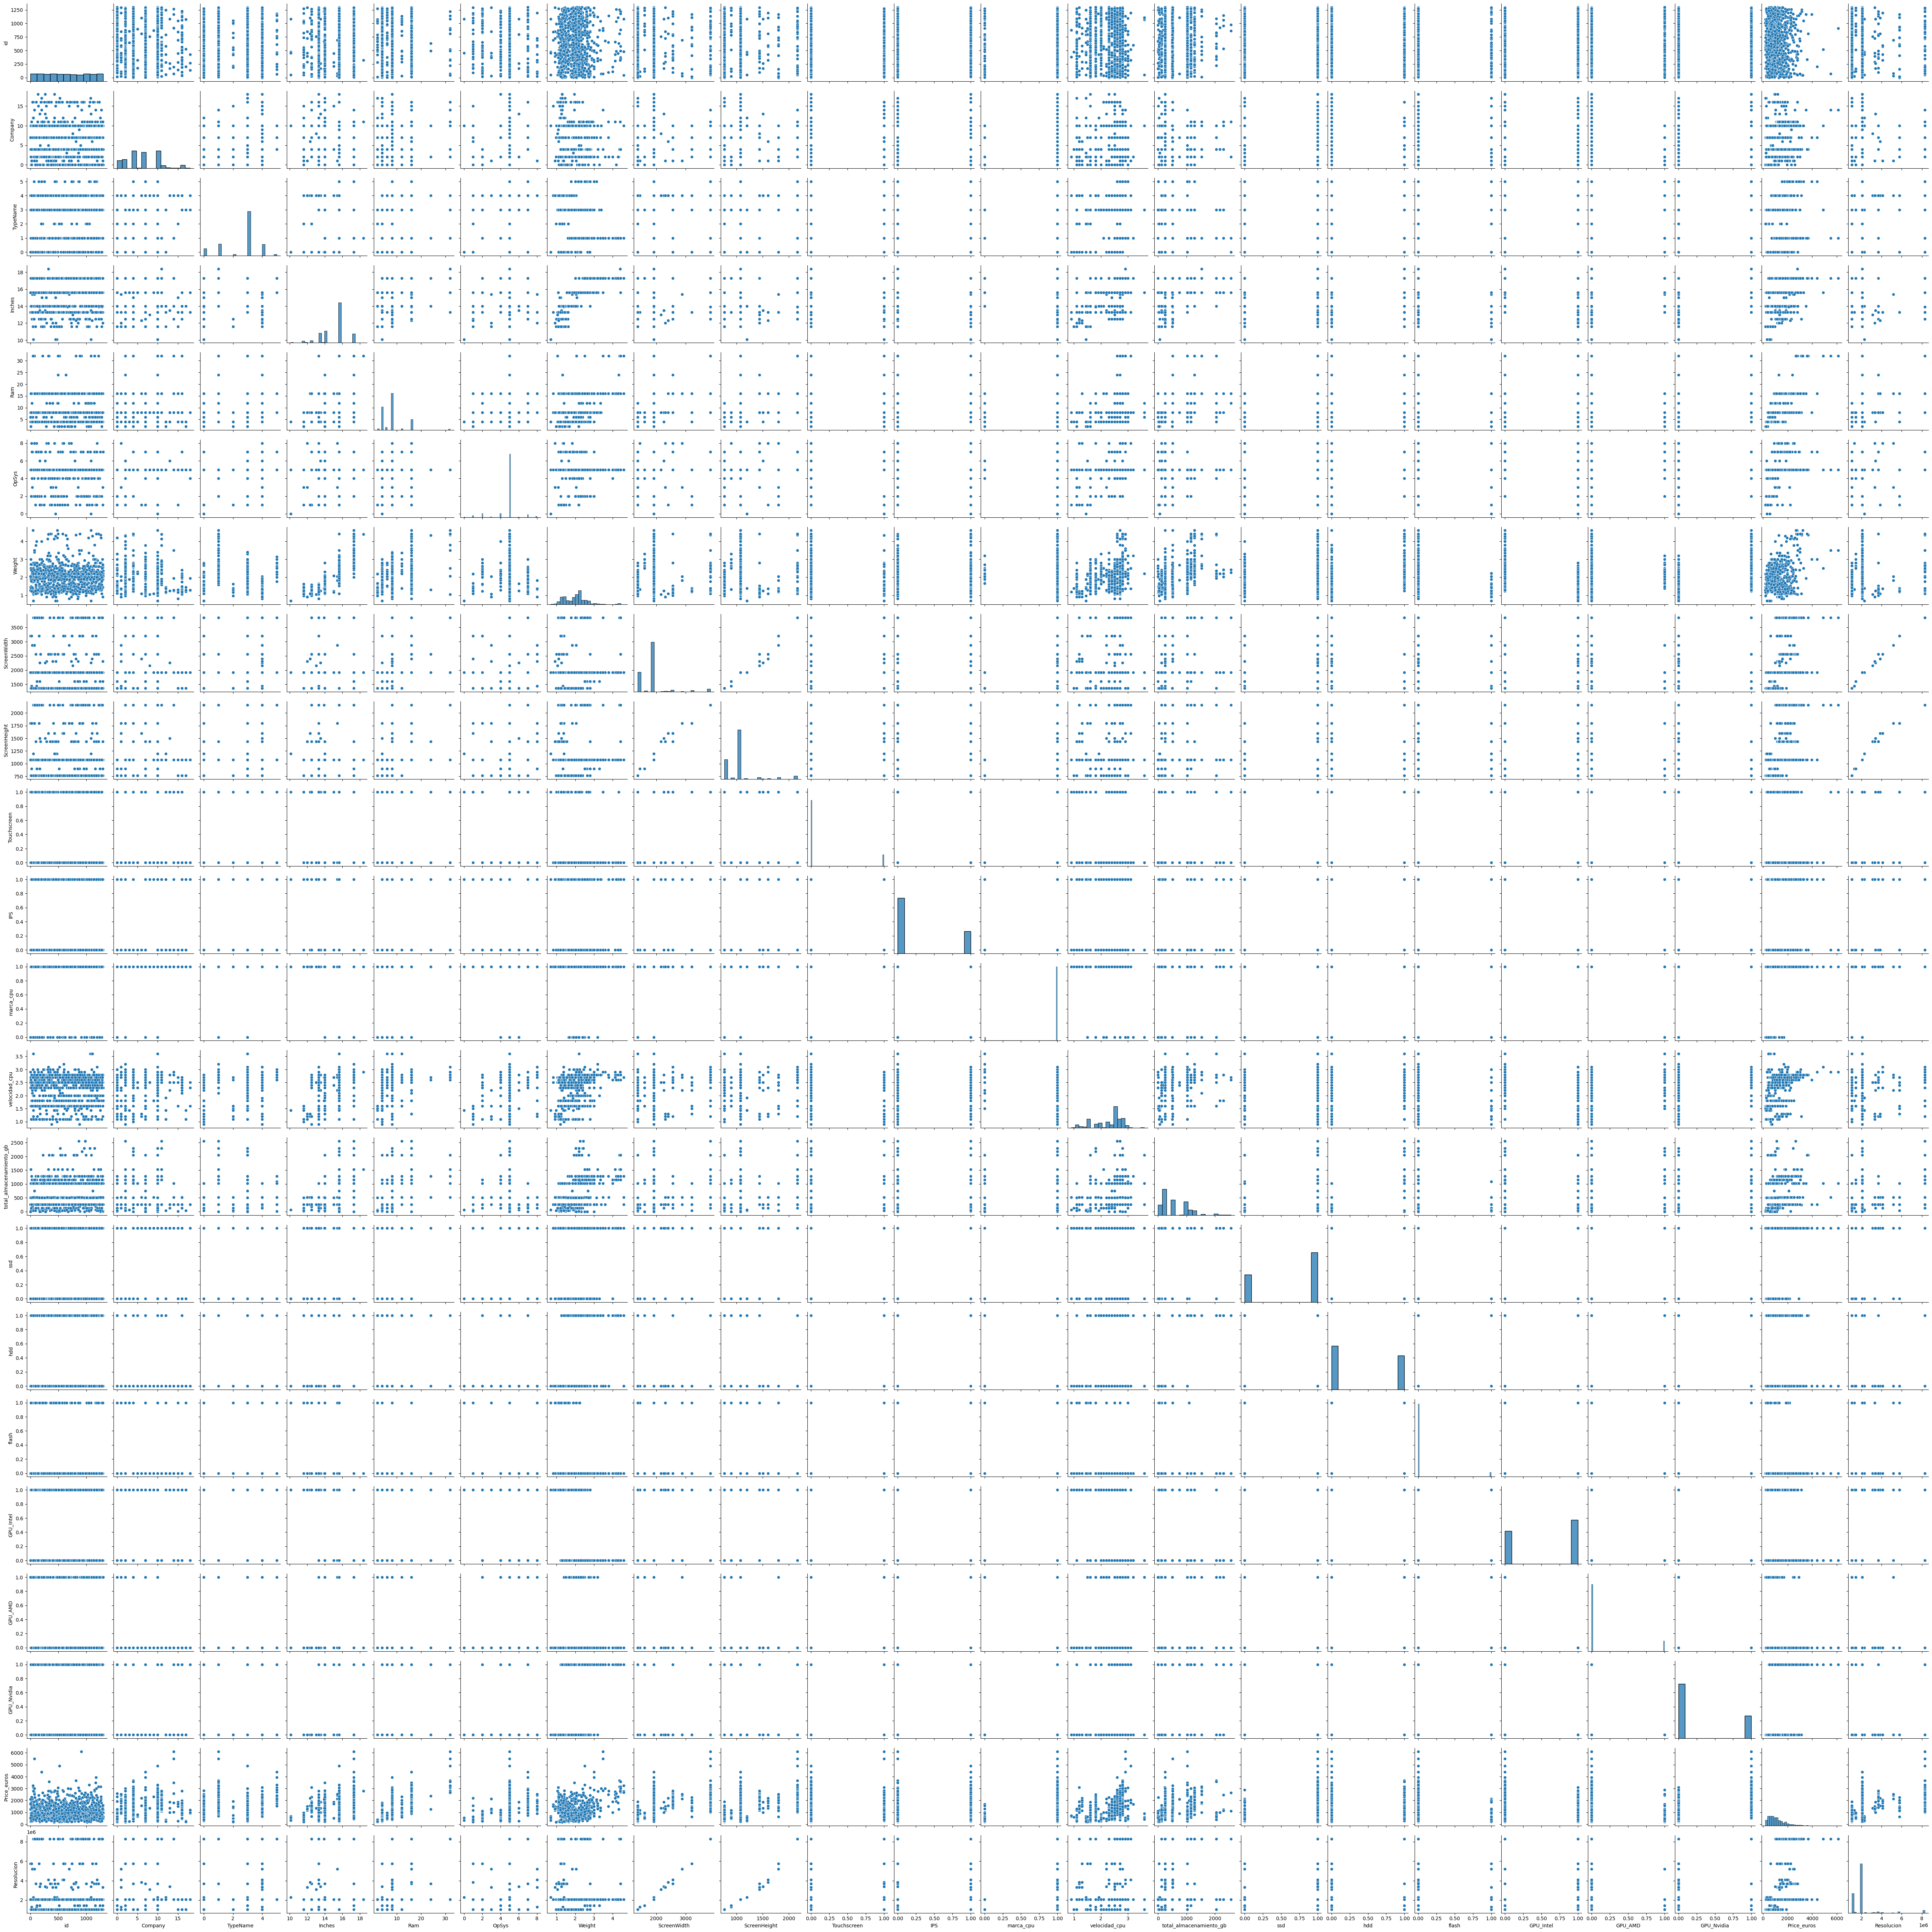

In [40]:
sns.pairplot(df_portatiles_mod)

In [41]:
df_portatiles_mod.corr()

,id,Company,TypeName,Inches,Ram,OpSys,Weight,ScreenWidth,ScreenHeight,Touchscreen,...,velocidad_cpu,total_almacenamiento_gb,ssd,hdd,flash,GPU_Intel,GPU_AMD,GPU_Nvidia,Price_euros,Resolucion
id,1.000000,0.020500,-0.004015,0.028012,-0.016759,-0.036257,0.032515,0.000068,-0.003057,-0.032643,...,0.004369,0.048967,0.012381,0.021130,-0.033892,-0.028650,0.036735,0.003664,-0.012740,-0.001695
Company,0.020500,1.000000,-0.001045,-0.101410,0.069520,0.131334,-0.139481,0.065330,0.058760,0.042420,...,0.149157,-0.113466,0.161936,-0.166080,-0.068696,0.083608,-0.097820,-0.017706,0.145581,0.042476
TypeName,-0.004015,-0.001045,1.000000,-0.050919,-0.256123,0.071786,-0.251714,-0.078400,-0.064099,-0.450048,...,-0.074327,-0.239152,-0.102713,-0.153150,-0.022077,0.142217,0.120333,-0.244380,-0.127641,-0.054134
Inches,0.028012,-0.101410,-0.050919,1.000000,0.245243,0.035291,0.830464,-0.042371,-0.066740,-0.370802,...,0.294392,0.495854,-0.066194,0.499956,-0.355984,-0.570118,0.192469,0.475359,0.077798,-0.051240
Ram,-0.016759,0.069520,-0.256123,0.245243,1.000000,0.144764,0.416750,0.480445,0.472879,0.125682,...,0.378765,0.364655,0.383968,0.014782,-0.186115,-0.351400,-0.090118,0.448988,0.747748,0.448450
OpSys,-0.036257,0.131334,0.071786,0.035291,0.144764,1.000000,0.009613,0.149040,0.152463,-0.007695,...,0.226947,0.024187,0.212360,-0.050628,-0.263548,-0.021728,-0.054286,0.064165,0.288204,0.126449
Weight,0.032515,-0.139481,-0.251714,0.830464,0.416750,0.009613,1.000000,0.013080,-0.008209,-0.275896,...,0.317567,0.520492,-0.009999,0.492448,-0.263597,-0.586449,0.102697,0.560181,0.231864,0.007519
ScreenWidth,0.000068,0.065330,-0.078400,-0.042371,0.480445,0.149040,0.013080,1.000000,0.995159,0.331172,...,0.208349,0.064075,0.386155,-0.222313,-0.101773,-0.152290,-0.090037,0.232680,0.585763,0.982695
ScreenHeight,-0.003057,0.058760,-0.064099,-0.066740,0.472879,0.152463,-0.008209,0.995159,1.000000,0.335793,...,0.194824,0.051849,0.379121,-0.231862,-0.081372,-0.137780,-0.090843,0.217524,0.582793,0.979518
Touchscreen,-0.032643,0.042420,-0.450048,-0.370802,0.125682,-0.007695,-0.275896,0.331172,0.335793,1.000000,...,-0.084027,-0.119584,0.134201,-0.234901,0.027108,0.239780,-0.144894,-0.152142,0.176573,0.336003


<Axes: >

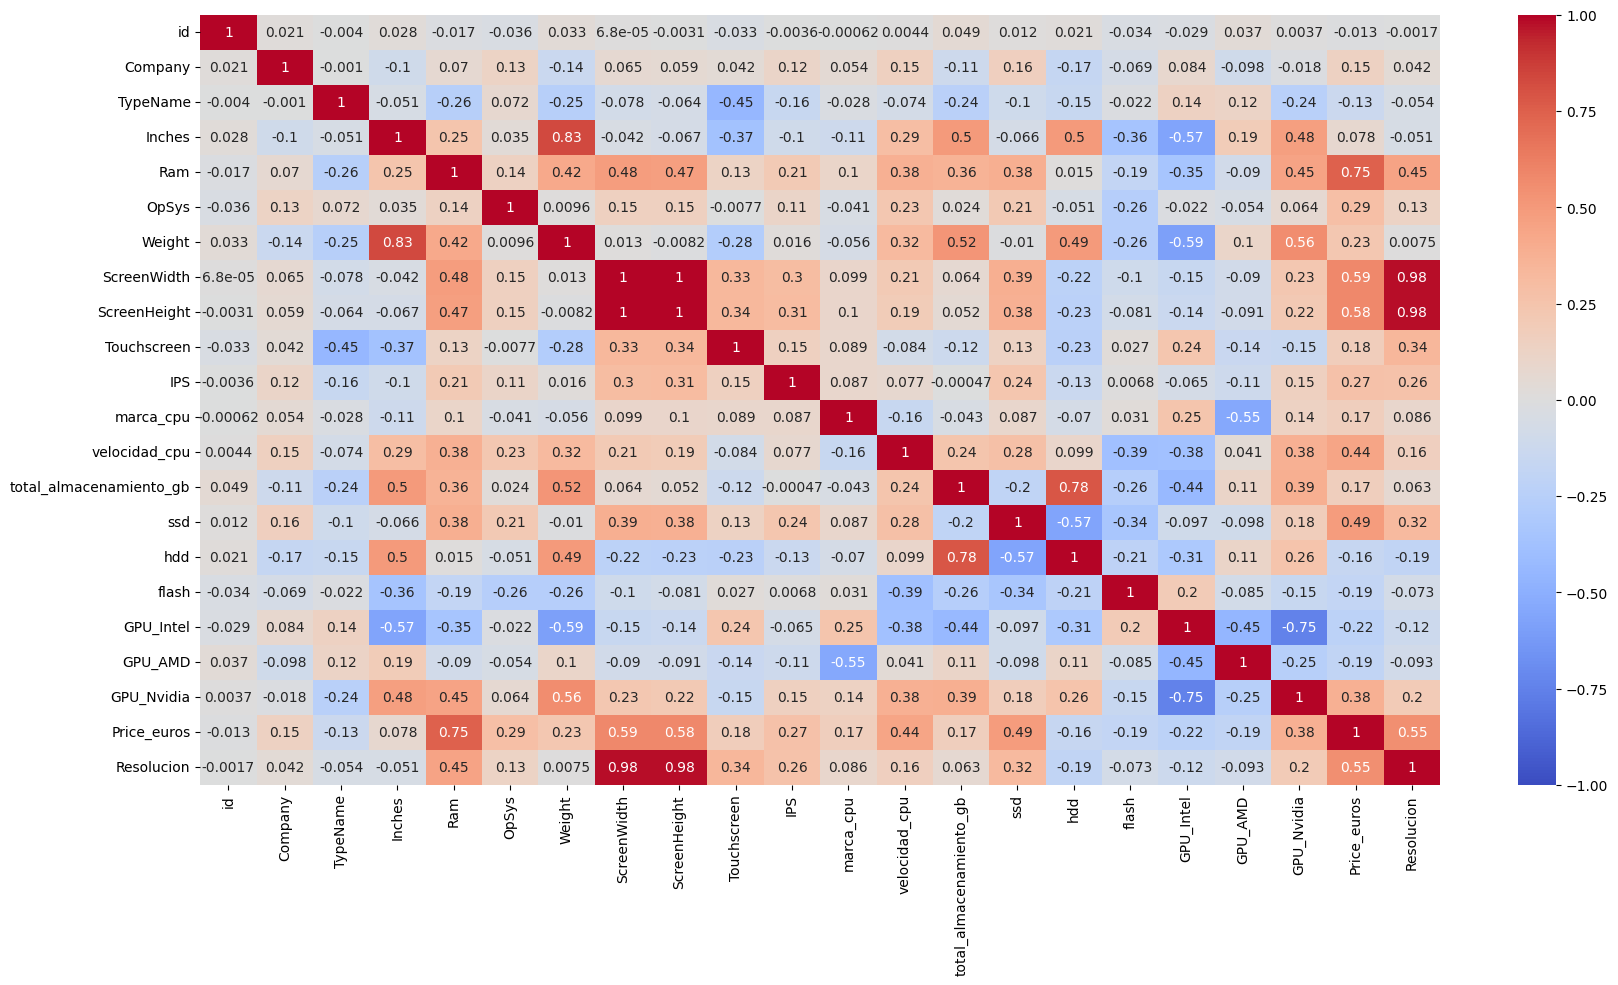

In [42]:
plt.figure(figsize=(20, 10))
sns.heatmap(df_portatiles_mod.corr(), annot=True, vmin=-1, cmap="coolwarm")

### Regresión lineal

In [43]:
df_prueba = df_portatiles_mod[["Ram", 
                               "Resolucion", 
                               "velocidad_cpu", 
                               "ssd", 
                               "hdd",
                               "total_almacenamiento_gb", 
                               "GPU_Nvidia", 
                               "IPS", 
                               "Touchscreen", 
                               "Weight"]]

In [44]:
X = df_prueba
y = df_portatiles_mod["Price_euros"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(729, 10)
(729,)
(183, 10)
(183,)


In [46]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
pred = linear_model.predict(X_test)

print("MAE: ", metrics.mean_absolute_error(y_test, pred))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred))
print("R2: ", metrics.r2_score(y_test, pred))

MAE:  314.63451011016235
RMSE:  443.99179689750025
MAPE:  0.29349898968121013
R2:  0.6313239785292148


In [90]:
df_prueba_02 = df_portatiles_mod[["TypeName",
                                  "marca_cpu",
                                  "OpSys",
                                  "Ram",
                                  "Resolucion", 
                                  "velocidad_cpu", 
                                  "ssd", 
                                  "GPU_Nvidia", 
                                  "Weight"]]

df_prueba_02

,TypeName,marca_cpu,OpSys,Ram,Resolucion,velocidad_cpu,ssd,GPU_Nvidia,Weight
0,3,1,5,8.0,1049088,2.7,0,0,2.36
1,3,1,5,4.0,1049088,1.1,0,0,2.00
2,3,1,7,8.0,2073600,2.3,1,0,1.20
3,1,1,5,16.0,8294400,2.8,1,1,4.42
4,4,1,7,8.0,2073600,2.4,1,0,1.26
...,...,...,...,...,...,...,...,...,...
907,0,1,1,4.0,1049088,1.6,0,0,1.25
908,3,1,5,4.0,2073600,2.3,1,0,1.20
909,3,0,5,8.0,1049088,2.2,0,0,2.40
910,4,1,5,8.0,2073600,2.8,1,0,1.36


In [91]:
df_encoded = pd.get_dummies(df_prueba_02, columns=["TypeName", "marca_cpu", "OpSys"], drop_first=False)
df_encoded

,Ram,Resolucion,velocidad_cpu,ssd,GPU_Nvidia,Weight,TypeName_0,TypeName_1,TypeName_2,TypeName_3,...,marca_cpu_1,OpSys_0,OpSys_1,OpSys_2,OpSys_3,OpSys_4,OpSys_5,OpSys_6,OpSys_7,OpSys_8
0,8.0,1049088,2.7,0,0,2.36,False,False,False,True,...,True,False,False,False,False,False,True,False,False,False
1,4.0,1049088,1.1,0,0,2.00,False,False,False,True,...,True,False,False,False,False,False,True,False,False,False
2,8.0,2073600,2.3,1,0,1.20,False,False,False,True,...,True,False,False,False,False,False,False,False,True,False
3,16.0,8294400,2.8,1,1,4.42,False,True,False,False,...,True,False,False,False,False,False,True,False,False,False
4,8.0,2073600,2.4,1,0,1.26,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907,4.0,1049088,1.6,0,0,1.25,True,False,False,False,...,True,False,True,False,False,False,False,False,False,False
908,4.0,2073600,2.3,1,0,1.20,False,False,False,True,...,True,False,False,False,False,False,True,False,False,False
909,8.0,1049088,2.2,0,0,2.40,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
910,8.0,2073600,2.8,1,0,1.36,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False


In [92]:
X = df_encoded
y = df_portatiles_mod["Price_euros"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

pred = linear_model.predict(X_test)

print("______________MÉTRICAS______________")
print("MAE: ", metrics.mean_absolute_error(y_test, pred))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred))
print("R2: ", metrics.r2_score(y_test, pred))

(729, 23)
(729,)
(183, 23)
(183,)
______________MÉTRICAS______________
MAE:  271.05884893412235
RMSE:  407.66692882321104
MAPE:  0.2602289498840157
R2:  0.6891821422081572


### Modelo de regresión polinómica

In [69]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

pred_poly = model_poly.predict(X_test_poly)

print("______________MÉTRICAS______________")
print("MAE: ", metrics.mean_absolute_error(y_test, pred_poly))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred_poly))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred_poly))
print("R2: ", metrics.r2_score(y_test, pred_poly))

______________MÉTRICAS______________
MAE:  276.69412199000107
RMSE:  411.61093937505166
MAPE:  0.26338983881438577
R2:  0.6831389794518392


In [84]:
st = StandardScaler()
st.fit(X_train)

X_train_st = st.transform(X_train)
X_test_st = st.transform(X_test)

In [70]:
poly_02 = PolynomialFeatures(degree=2)
X_train_poly = poly_02.fit_transform(X_train_st)
X_test_poly = poly_02.transform(X_test_st)

model_poly_02 = LinearRegression()
model_poly_02.fit(X_train_poly, y_train)

pred_poly_02 = model_poly_02.predict(X_test_poly)

print("______________MÉTRICAS______________")
print("MAE: ", metrics.mean_absolute_error(y_test, pred_poly_02))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred_poly_02))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred_poly_02))
print("R2: ", metrics.r2_score(y_test, pred_poly_02))

______________MÉTRICAS______________
MAE:  280.4543782408523
RMSE:  417.5248407268865
MAPE:  0.26493920510539787
R2:  0.6739684431902031


### Ridge

In [93]:
ridge = Ridge(alpha=25)
ridge.fit(X_train_st, y_train)

pred_r = ridge.predict(X_test_st)

print("______________MÉTRICAS______________")
print("MAE: ", metrics.mean_absolute_error(y_test, pred_r))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred_r))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred_r))
print("R2: ", metrics.r2_score(y_test, pred_r))

______________MÉTRICAS______________
MAE:  270.9651976883502
RMSE:  409.7908694568713
MAPE:  0.26009574461276275
R2:  0.6859349894905897


### Lasso

In [94]:
lasso = Lasso(alpha=8)
lasso.fit(X_train_st, y_train)

pred_l = lasso.predict(X_test_st)

print("______________MÉTRICAS______________")
print("MAE: ", metrics.mean_absolute_error(y_test, pred_l))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred_l))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred_l))
print("R2: ", metrics.r2_score(y_test, pred_l))

______________MÉTRICAS______________
MAE:  270.51269943389934
RMSE:  410.3349584348059
MAPE:  0.25701055831703534
R2:  0.6851004528351488


In [25]:
df_original = pd.read_csv("data/train.csv", sep=",")
df_original.head()

,id,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,268,1002,Dell,Inspiron 5567,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,AMD Radeon R7 M445,Windows 10,2.36kg,749.00
1,347,867,Asus,X541NA (N4200/4GB/1TB/W10),Notebook,15.6,1366x768,Intel Pentium Quad Core N4200 1.1GHz,4GB,1TB HDD,Intel HD Graphics 505,Windows 10,2kg,449.00
2,353,966,Toshiba,Portege Z30-C-1CW,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.2kg,1460.00
3,578,767,Dell,Alienware 17,Gaming,15.6,IPS Panel 4K Ultra HD 3840x2160,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,4.42kg,2868.99
4,42,1241,Dell,Latitude E7270,Ultrabook,12.5,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 7,1.26kg,1713.37


### Elastic net

In [26]:
elastic_net = ElasticNet(alpha = 0.0001, l1_ratio = 0.7)
elastic_net.fit(X_train_st, y_train)

pred_en = elastic_net.predict(X_test_st)

print("______________MÉTRICAS______________")
print("MAE: ", metrics.mean_absolute_error(y_test, pred_en))
print("RMSE: ", metrics.root_mean_squared_error(y_test, pred_en))
print("MAPE: ", metrics.mean_absolute_percentage_error(y_test, pred_en))
print("R2: ", metrics.r2_score(y_test, pred_en))

______________MÉTRICAS______________
MAE:  271.4570044454955
RMSE:  409.3853313274692
MAPE:  0.2607591686039745
R2:  0.6865562933047077


c:\Users\Administrador\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.532e+07, tolerance: 3.672e+04
  model = cd_fast.enet_coordinate_descent(


# TABLA DE PREDICCIONES

In [27]:
# Preprocesamiento test.csv de Kaggle
df_test = pd.read_csv("data/test_kaggle_procesado.csv")  # el que te dan en Kaggle
df_test_proc = df_test[["TypeName","marca_cpu","OpSys","Ram","ScreenWidth",
                        "velocidad_cpu","ssd","hdd","total_almacenamiento_gb",
                        "GPU_Nvidia","IPS","Touchscreen","Weight"]]

df_test_encoded = pd.get_dummies(df_test_proc, columns=["TypeName","marca_cpu","OpSys"], drop_first=False)

# Asegurar que el test tenga las mismas columnas que el train
df_test_encoded = df_test_encoded.reindex(columns=X_train.columns, fill_value=0)

X_test_st = st.transform(df_test_encoded)

# Predecir
predictions = lasso.predict(X_test_st)

predictions


array([ 1.62847062e+03,  4.95106811e+02,  3.35355205e+02,  8.46418502e+02,
        7.00045149e+02,  1.36896834e+03,  1.54331726e+03,  4.22529668e+02,
        4.85999865e+03,  9.74731378e+02,  1.07731963e+03,  2.47687378e+02,
        6.28775161e+01,  3.10084868e+02,  4.10449001e+02,  7.40418311e+02,
        4.54750002e+02,  9.57296486e+02,  9.67071915e+02,  1.01523952e+03,
        1.14538014e+03,  4.28746331e+02,  1.27629050e+03,  8.85535811e+02,
        1.54331726e+03,  1.68596951e+02,  5.23262874e+02,  3.50895766e+01,
        8.42594318e+02,  1.60512915e+02,  6.72834827e+02,  6.65175363e+02,
        1.50844748e+03,  6.16284927e+02,  9.07733442e+01,  1.54331726e+03,
        5.15920794e+02,  4.28428947e+02,  2.67282957e+03,  3.10665073e+02,
        2.12817592e+02,  5.50790579e+02,  1.00758006e+03,  1.53565780e+03,
        8.85535811e+02,  1.07731963e+03,  4.62753679e+02,  2.66305414e+03,
        2.53534968e+02,  1.07731963e+03,  7.34914934e+02,  4.01218626e+02,
        6.72834827e+02,  

In [28]:
df_test

,id,Company,TypeName,Inches,Ram,OpSys,Weight,ScreenWidth,ScreenHeight,Touchscreen,IPS,marca_cpu,velocidad_cpu,total_almacenamiento_gb,ssd,hdd,flash,GPU_Intel,GPU_AMD,GPU_Nvidia
0,181,6,4,13.3,16.0,4,1.30,3840,2160,0,1,1,2.7,512.0,1,0,0,1,0,0
1,708,0,3,15.6,8.0,4,2.20,1366,768,0,0,0,2.7,256.0,1,0,0,0,1,0
2,862,0,3,15.6,4.0,1,2.40,1366,768,0,0,1,2.0,500.0,0,1,0,1,0,0
3,1064,6,3,14.0,8.0,6,1.43,1920,1080,0,0,1,2.3,256.0,1,0,0,1,0,0
4,702,6,3,13.3,8.0,4,1.34,1920,1080,0,1,1,2.5,256.0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386,1281,9,1,15.6,8.0,3,2.40,1920,1080,0,1,1,2.8,256.0,1,0,0,0,0,1
387,524,9,1,15.6,16.0,4,3.31,1920,1080,0,1,1,2.6,512.0,1,0,0,0,0,1
388,1015,6,3,15.6,4.0,3,1.96,1366,768,0,0,1,2.5,500.0,0,1,0,1,0,0
389,1236,6,3,15.6,4.0,4,2.10,1920,1080,0,0,0,1.5,500.0,0,1,0,0,1,0


In [29]:
# Crear submission.csv
submission = pd.DataFrame({"id": df_test["id"], "Price_euros": predictions})
submission.to_csv("data/sample_submission.csv", index=False)

In [30]:
submission

,id,Price_euros
0,181,1628.470622
1,708,495.106811
2,862,335.355205
3,1064,846.418502
4,702,700.045149
...,...,...
386,1281,1269.312679
387,524,1535.657800
388,1015,497.623464
389,1236,-139.259349
